# Predicting Nuclear Ground State Spin

This project explores nuclear ground state data from the IAEA LiveChart API.

Goals:
- Explore nuclear spin distributions
- Investigate even-even / odd-even structure
- Engineer physically meaningful features
- Train machine learning models to predict nuclear spin

In [18]:
import sys
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent
DB_PATH = BASE_DIR / "data" / "nuclides.db"
sys.path.append(str(Path.cwd().parent))

with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query(
        "SELECT * FROM ground_states",
        conn
    )

df.head()

,id,z,n,a,symbol,nuclide,ground_state_jpi,ground_state_j,parity
0,1,0,1,1,n,n-1,1/2+,0.5,+
1,2,0,4,4,n,n-4,0+,0.0,+
2,3,0,6,6,n,n-6,NaN,NaN,NaN
3,4,1,0,1,H,H-1,1/2+,0.5,+
4,5,1,1,2,H,H-2,1+,1.0,+


In [13]:
df.shape

(3386, 9)

In [14]:
df.dtypes

id                    int64
z                     int64
n                     int64
a                     int64
symbol                  str
nuclide                 str
ground_state_jpi        str
ground_state_j      float64
parity                  str
dtype: object

In [15]:
df["ground_state_j"].value_counts().sort_index()

ground_state_j
0.0     894
0.5     272
1.0     173
1.5     308
2.0     129
2.5     340
3.0      94
3.5     225
4.0      50
4.5     171
5.0      50
5.5      27
6.0      38
6.5       2
7.0      23
8.0      11
9.0       1
10.0      2
Name: count, dtype: int64

### J Subsets
- We want to exclude any nuclide where there is a NULL ground state J.
- Then we create subsets of even-even, odd-odd, and odd-A (A=Z+N) nuclides.

In [20]:
# Keep only J is not null
spin_df = df[df["ground_state_j"].notna()]
# EVEN Z - EVEN N
ee_df = spin_df[
    (spin_df["z"] % 2 == 0) &
    (spin_df["n"] % 2 == 0)
]
# ODD Z - ODD N
oo_df = spin_df[
    (spin_df["z"] % 2 == 1) &
    (spin_df["n"] % 2 == 1)
]
# ODD A (Z + N is ODD)
oa_df = spin_df[
    (spin_df["a"] % 2 == 1)
]

## Ground State J Distribution by Nucleon Configuration

- **Even Z / Even N** : these universally have a ground state J of 0+ (+ parity)
- **Odd - Odd and Odd - A** : These don't seem to have an obvious pattern of J distribution

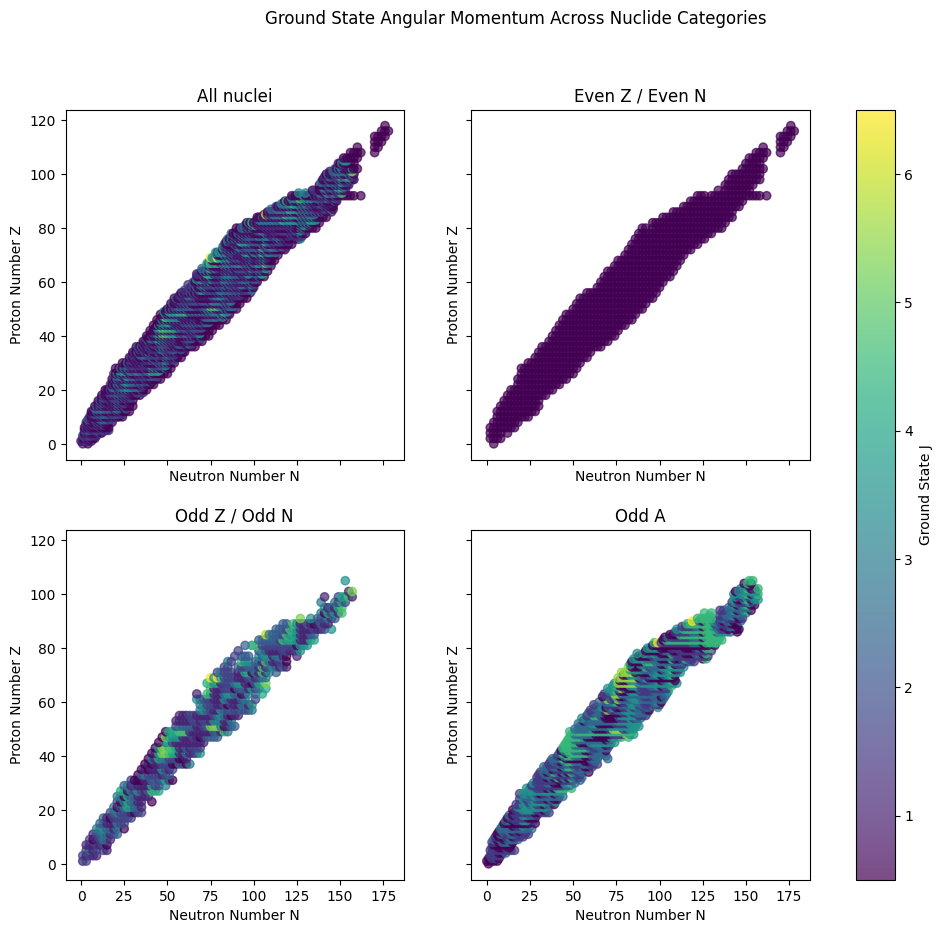

In [21]:
from analysis.eda import plot_pairing_category_grid
plot_pairing_category_grid(spin_df, ee_df, oo_df, oa_df)

## Ground State Spin (J) Distribution by Parity

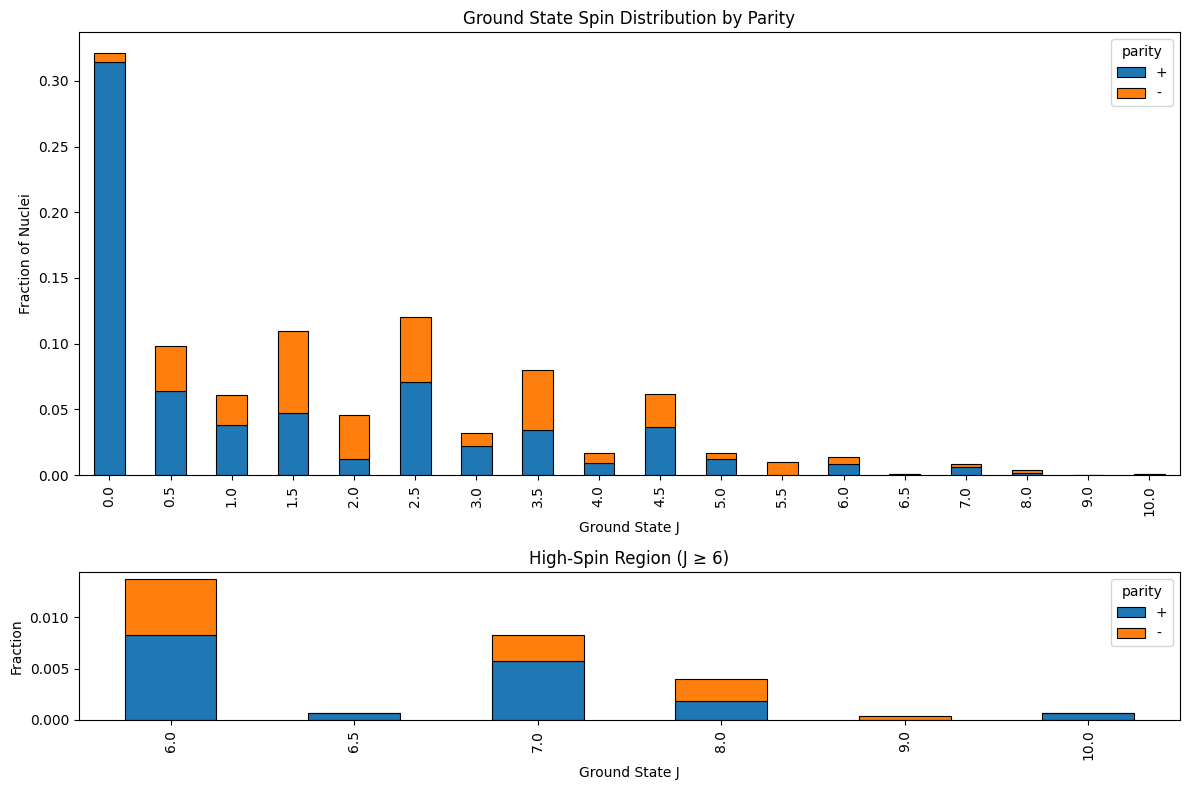

In [22]:
from analysis.eda import plot_spin_distribution
plot_spin_distribution(spin_df)